# Lesson 114 · OGB error analysis: where does the GCN lose?

Teacher solution · Three live TODO/CHECK tasks. Full graph analysis uses archived predictions; full training is separately gated.

In [1]:
# @colab-bootstrap · missing-package installation only; full author pins are linked below.
import importlib.util, importlib.metadata, subprocess, sys
required={'torch':'torch==2.8.0','numpy':'numpy==2.2.6','pandas':'pandas==2.3.2','ogb':'ogb==1.3.6','sklearn':'scikit-learn==1.7.1'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing: subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Python',sys.version)
print({k:importlib.metadata.version(k) for k in ['torch','numpy','pandas','ogb']})


Python 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'torch': '2.13.0+cpu', 'numpy': '2.5.0', 'pandas': '3.0.3', 'ogb': '1.3.6'}


## Runtime and evidence

Allow about 2 GiB RAM for the default analysis. The 8 MiB evidence bundle is SHA-256 checked and contains every prediction, all raw edges, labels, years and split IDs. Before this lesson is published, use a local repository checkout or copy `labs/evidence/l114/analysis-inputs.npz` beside this notebook as `l114-analysis-inputs.npz`; the remote fallback only works after publication. Author runtime: Python 3.12, torch 2.8.0, NumPy 2.2.6, pandas 2.3.2, OGB 1.3.6, scikit-learn 1.7.1. Original GCN parity additionally uses PyG 2.6.1. Live Colab NOT_CHECKED. [Exact protocol](https://avistian.github.io/relational/labs/l114-reproduction.md).

## The question behind one accuracy number

A model can win overall and lose on an identifiable part of the graph. Your task is to turn that statement into a reproducible **error report**: name the population, count its nodes, compare the same questions, explain what the result does and does not establish, and propose the next experiment.

[Lesson 112](https://avistian.github.io/relational/lessons/0112-ogb-gcn-reproduction.html) reproduced a full-batch Graph Convolutional Network (GCN) on ogbn-arxiv. [Lesson 113](https://avistian.github.io/relational/lessons/0113-scaling-ogb.html) moved to a different, much larger graph and studied scalable training. Here we return to arxiv because it contains publication years as well as graph structure. The [official OGB documentation](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv) defines the task: predict one of 40 subject categories from a paper's features and citation context.

**The win.** By the end, you can defend a sentence of the form: “On this precisely defined set of n nodes, the GCN differs from a feature-only baseline by Δ percentage points; here is the evidence and the next check.” This is the same habit you will need when assessing where relational learning beats feature engineering in Year 4.

**Read first:** [Hu et al., OGB §4.3 and Table 6](https://arxiv.org/html/2005.00687v6#S4.SS3), then the [pinned MLP source](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/mlp.py). Trace `train` before `forward`: which rows enter batch normalization?

**Recall before reading:** What does validation select? Which labels enter a transductive GCN loss? Why is seed SD different from uncertainty over datasets?



## 1 · Freeze the questions before studying the mistakes

A **slice** is a subset of evaluation nodes satisfying a rule. “Test papers with one or two unique neighbors” is a slice. “The hardest papers” is not a reproducible rule until you define how hardness was measured and which data selected them.

**Population.** We use every official validation node (29,799) and test node (48,603), with all 169,343 feature rows and the released citation graph available to the GCN. Validation papers are from 2018; test papers are from 2019–2020. Features have 128 numeric coordinates. Labels are integers 0–39. This is a **transductive** benchmark: the graph and feature rows of evaluation nodes may be visible during training, while their labels are excluded from the training loss.

**Held fixed.** Both models predict the same released nodes with the same labels and feature vectors. Each is selected by its own highest validation accuracy, taking the first epoch in a tie. Each reported run has 500 training epochs. An **epoch** here is one complete pass through the training labels with one optimizer update.

**Varied.** We compare the published GCN and the published multi-layer perceptron (MLP), a network that transforms each node's feature vector without exchanging neighbor messages. Their source protocols differ in normalization population and initialization as well as adjacency. This is a comparison of two released baselines, not an intervention that removes edges from an otherwise identical training process.

**Frozen slice rules.** Degree: 0, 1–2, 3–5, 6–10, 11–20, 21–50, 51+. Homophily: undefined, [0,.25), [.25,.50), [.50,.75), [.75,1]. Class: all 40 categories. Year: each observed publication year. Within a family, every node belongs to exactly one slice. Across families, slices overlap.

> **Scope check.** A year-based label split does not guarantee strict historical forecasting. The released GCN can use later graph context. Recall [Lesson 109](https://avistian.github.io/relational/lessons/0109-database-timestamp-contracts.html) and the distinction between event time and information availability. We preserve OGB's protocol rather than silently replacing its graph with time-filtered snapshots.



## 2 · Model architecture: what the simple baseline actually does

> **In plain terms.** The MLP sees the words summarized in one paper's vector. The GCN can combine that vector with citation-neighbor information. A strong comparison requires reproducing the MLP carefully too.

The MLP receives a matrix X with one row per paper and 128 columns. A **linear layer** computes XWᵀ+b: W mixes feature coordinates and b adds a learned offset. It produces 256 coordinates in each of the first two layers and 40 class scores in the last layer.

**Hidden blocks.** Each hidden linear output passes through batch normalization, ReLU, and dropout. Batch normalization standardizes each coordinate using the current training batch and keeps running statistics for evaluation. ReLU replaces negative values by zero. During training, dropout randomly removes half the hidden coordinates and rescales those retained; it is disabled at evaluation. The final log-softmax converts scores into log probabilities whose exponentials sum to one per row.

**Objective.** Negative log-likelihood penalizes the log probability of the correct class: a correct-class probability of 0.8 incurs −log(0.8)≈0.223, while 0.2 incurs ≈1.609. Average this loss over training nodes. Adam adjusts weights using gradients, at learning rate 0.01. No label from validation or test participates in that objective.

<figure class="error-figure" tabindex="0">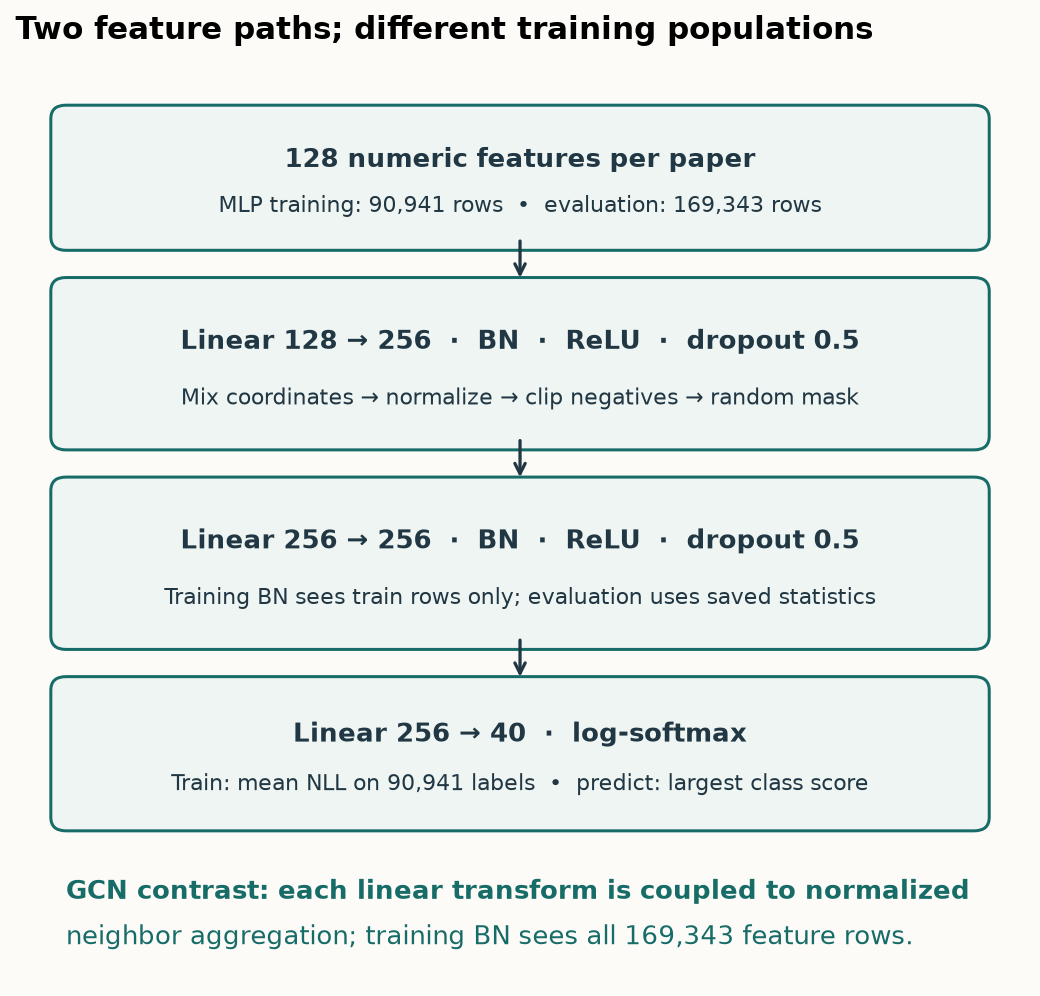<figcaption>Released MLP computation: two normalized hidden blocks, 40 output scores, train-only BN population. The GCN comparison changes more than adjacency.</figcaption></figure>

**The easy-to-miss distinction.** The released MLP calls `model(x[train_idx])` during training. Its batch normalization sees 90,941 training rows. The released GCN calls its model on the complete graph and masks the loss afterward; its normalization sees all 169,343 rows. Changing the MLP to process all nodes before masking the loss changes the released experiment, even if the labels remain correctly masked.

**Selection and inference.** After each epoch, switch to evaluation mode and score the full graph's feature rows. Save the first best validation state, including batch-normalization running statistics. Restore it before archiving predictions. Neither last-epoch accuracy nor the highest test accuracy is a replacement for the selected predictor.

**Predict:** would changing only held-out feature rows alter a single MLP training update?

<details><summary>Check your reasoning</summary><p>No: the released training forward pass includes only training rows. It can change validation predictions and therefore later checkpoint selection, but not that one optimization update. The source audit tests the one-epoch statement using held-out features and labels replaced by extreme values.</p></details>



## 3 · Count neighbors before you count errors

**Degree** is the number of distinct neighbors of a node. We use the binary undirected citation graph without self-loops for this diagnostic. A citation in both directions still creates one neighbor, not two. The self-loop used by GCN computation does not make a paper its own external neighbor.

**Homophily** measures label agreement among those neighbors. For node i with neighbor set N(i), define hᵢ = number of neighbors j with yⱼ=yᵢ, divided by |N(i)|. The bars denote set size. A value of 1 means all neighbors share the label; 0 means none do. An isolated node has degree zero, so the ratio is undefined. We keep it in an explicit “undefined” slice rather than replacing it with zero.

**Worked example.** Node A has label 0, B has label 0, and C has label 1. Edges connect A–B and B–C. For B, degree=2 and homophily=1/2. For A, degree=1 and homophily=1. For C, degree=1 and homophily=0. Repeating the record A→B does not change any answer. Adding a self-loop to C must not turn its diagnostic homophily into 1/2.

<figure class="error-figure" tabindex="0">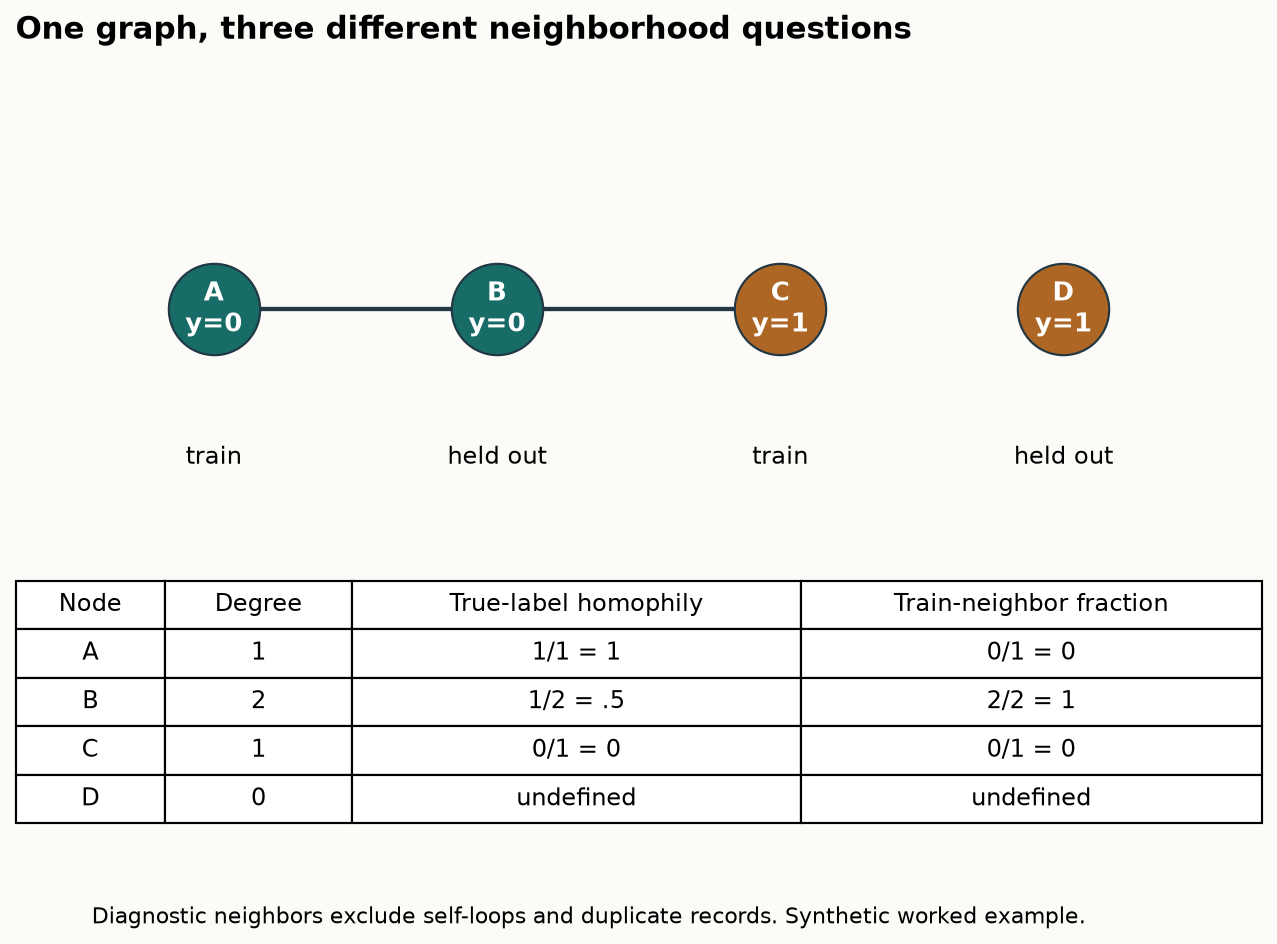<figcaption>Synthetic four-node trace: unique neighbors, true-label agreement, known training-neighbor fraction, and an isolate.</figcaption></figure>

**Task 1 · graph semantics.** Implement `neighborhood_properties`: deduplicate undirected neighbors, exclude self-loops, compute degree and homophily, and retain undefined ratios. Also compute the fraction of neighbors belonging to the training split. That fraction measures access to training nodes; it does not require the focal node's label and is not homophily.

**Information boundary.** True-label homophily requires the focal label and neighbor labels, including held-out labels here. True class also requires the answer we are predicting. They are legitimate retrospective diagnostics after evaluation, but cannot be supplied to a serving-time model selector. Degree and known training-neighbor membership are different: they can be computed without hidden labels when the graph itself is available.

<details><summary>Can we deploy “use MLP when true homophily is low”?</summary><p>No. A future unlabeled paper has no known true class, and many neighbors may also lack labels. The diagnostic suggests a hypothesis about harmful context. A deployable rule would need label-free signals and its own validation protocol. Substituting predicted labels changes the quantity and needs separate testing.</p></details>



## 4 · Compare mistakes on the same nodes

> **In plain terms.** Do not just place two accuracies next to each other. Count where their answers disagree, using the same denominator.

**Accuracy** equals correct predictions divided by evaluated nodes. For slice S with n nodes, accuracy(S)=Σᵢ∈S 1[predᵢ=yᵢ]/n. The indicator 1[statement] is 1 when the statement is true and 0 otherwise. An empty slice has no accuracy; report “no nodes,” not 0%.

**Worked example.** On ten nodes, both models get five right; GCN alone gets two right; MLP alone gets one right; both miss two. GCN accuracy is 7/10=70%, MLP is 6/10=60%, and their difference is +10 **percentage points** (pp). The difference also equals 100×(2−1)/10. This is not a 10% relative improvement, and the two models' mistakes are not independent.

**Task 2 · retain the pairing.** Implement `slice_metrics`. Inputs contain one prediction row per seed, indexed by the same global node IDs. Return n, both accuracies, their pp difference, and the four disagreement counts for each seed. Slice IDs need not be sorted. Do not accidentally index a subset as if it were the whole graph.

**Seed variation.** We report ten individual runs, their mean, and **sample standard deviation**: the square root of the sum of squared deviations divided by 9. This describes variation from repeated training on this fixed graph. It is not a confidence interval for future databases. Nodes connected by citations are dependent; pretending every node is an independent experiment overstates certainty. Indexing MLP seed k beside GCN seed k is a reproducible display convention, not shared initialization across architectures.

**Why slice sizes matter.** Overall accuracy is a weighted average of slice accuracies when the slices form a disjoint partition. The weight for a slice is its n divided by the population size. Averaging slice percentages equally instead answers a different question.

<figure class="error-figure" tabindex="0">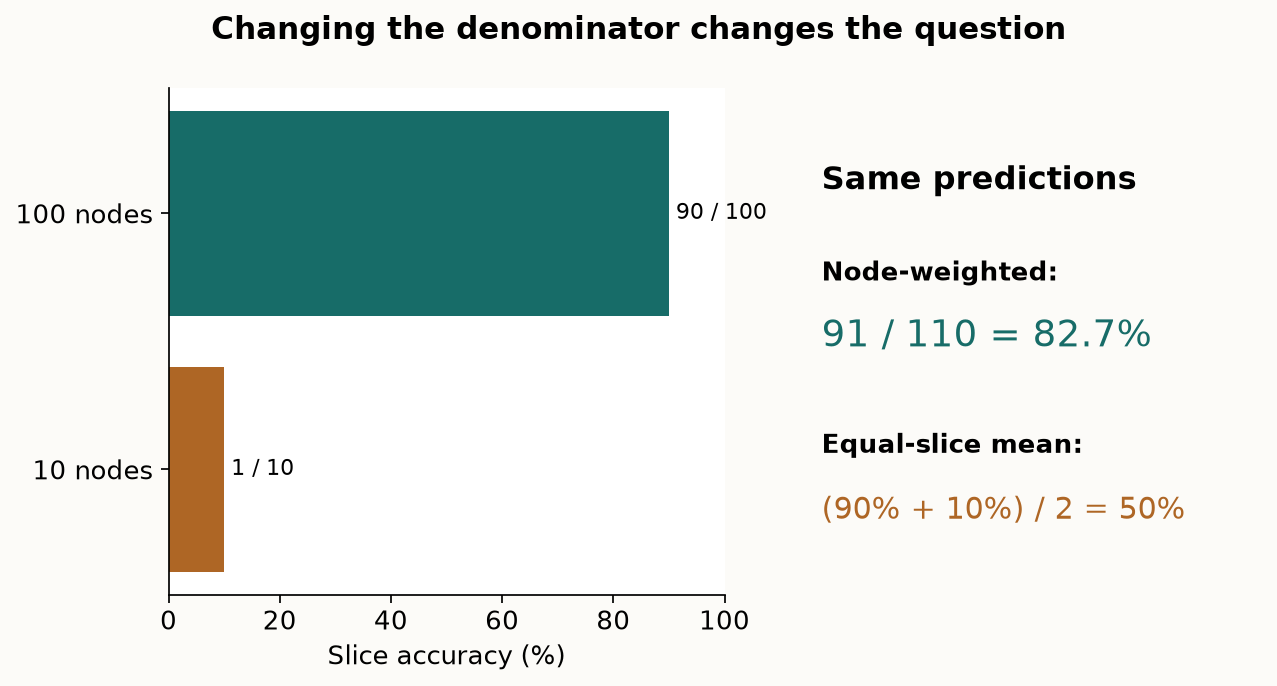<figcaption>Synthetic denominator example: 91 correct of 110 nodes gives 82.7%; averaging two slice percentages gives 50%.</figcaption></figure>

**Predict:** a model is correct on 90/100 nodes in one slice and 1/10 in another. Is overall accuracy 50% or about 82.7%?

<details><summary>Check the denominator</summary><p>It is 91/110≈82.7%. The equal-slice mean is (90%+10%)/2=50%; it gives ten difficult nodes the same weight as one hundred easier ones. Both summaries can be useful if named clearly, but only the node-weighted value reconstructs OGB accuracy. The analysis checks this identity for every family, model and seed.</p></details>



## 5 · Full reproduction before interpretation

The fresh MLP experiment is **ten full-data runs × 500 epochs**, following the released architecture and training protocol. The GCN's ten complete L112 training runs are reused, with fresh all-node checkpoint replay in this lesson. The published targets are from OGB Table 6. A predeclared mean tolerance of 0.5 pp gives a descriptive numerical verdict; matching a mean cannot establish historical bitwise identity.

**Author-reference evidence, separate from your notebook execution.**

| Model / population | Mean accuracy | Seed SD | Paper mean | Verdict |
|---|---:|---:|---:|---|
| GCN / valid | 73.1041% | 0.0977 pp | 73.00% | CLOSE |
| GCN / test | 71.8480% | 0.3119 pp | 71.74% | CLOSE |
| MLP / valid | 57.9110% | 0.1050 pp | 57.65% | CLOSE |
| MLP / test | 55.8036% | 0.0652 pp | 55.50% | CLOSE |

GCN training reused from L112; MLP training fresh in L114. Both models' **3,386,860 combined final node predictions** were replayed through their original classes with zero class mismatches. The MLP's recorded pilot-plus-ten-run resource estimate is **USD0.0629**, excluding unitemized build/startup/storage overhead; the conservative resource ceiling is USD1.372536 within the USD10 aggregate plan. [Complete evidence](https://avistian.github.io/relational/labs/evidence/l114/summary.json).

**Verification chain.** Archive and split identities → source-model output/gradient/optimizer checks → full histories and selected checkpoints → all-node original-model inference replay → independent correct-count reconstruction with the official evaluator. The graph-property implementation is checked separately against SQLite joins and grouping over the complete graph. No failed seed is dropped.

> **Scope check.** We reproduce selected MLP and GCN table entries, not every experiment in the OGB paper. The slice analysis is a new course experiment: the paper does not provide these exact slice targets. Modern libraries, explicit independent seeds, and the GCN sparse backend remain recorded deviations. Original tuning and historical randomness are not recovered.



## 6 · Let validation nominate the failure slice

Looking through many slices and reporting the most dramatic test gap is an **exploratory** discovery. It is worth investigating, but its dramatic size was part of why you chose it. A fresh evaluation must carry more weight than a story selected on that same evaluation.

**Our rule, written before MLP test results.** Among validation degree, homophily and class slices with at least 200 nodes, choose the smallest mean GCN-minus-MLP gap. Break ties by family name, then slice name. Keep year out of this selection because the validation year and test years do not overlap. Apply the chosen slice definition unchanged to test. The minimum support reduces tiny-slice noise but does not make the result causal or eliminate selection effects.

**Task 3 · separate nomination from evaluation.** Implement `choose_failure` and call it with validation rows only. Return no selection when none meets the minimum count. Keep all test rows in the report, but distinguish the validation-nominated slice from a new test-only discovery.

**Validation-nominated rule: true-label homophily < 0.25.**

| Population | Nodes | GCN mean ± seed SD | MLP mean ± seed SD | GCN − MLP |
|---|---:|---:|---:|---:|
| Validation | 5,179 | 18.75% ± 0.46 pp | 29.22% ± 0.38 pp | -10.47 pp |
| Test, same rule | 8,585 | 17.28% ± 0.73 pp | 27.22% ± 0.25 pp | -9.94 pp |

Across seeds, the test slice averages **695.9 GCN-only correct** and **1549.5 MLP-only correct** nodes. Their difference, divided by 8,585, gives the -9.94 pp accuracy gap. These are mean counts over ten runs, so decimals are expected. Both models are poor here: MLP's relative advantage does not make 27.22% accuracy adequate.

<figure class="error-figure" tabindex="0">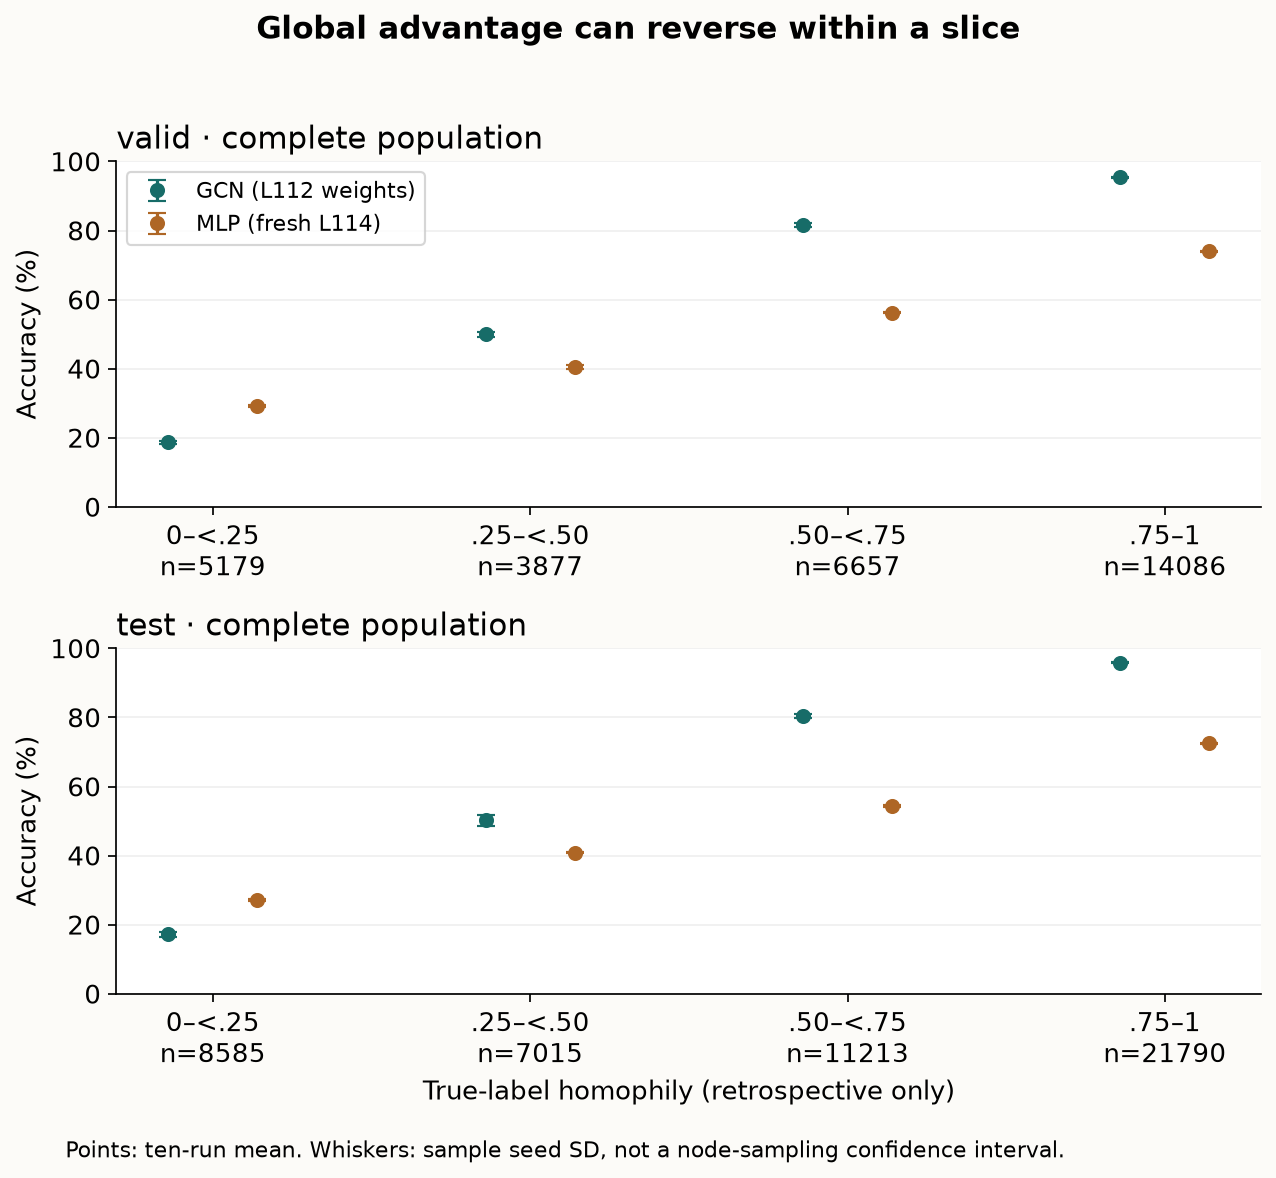<figcaption>Complete validation and test homophily slices. Points are ten-run means; whiskers are sample seed SD. Empty isolate slices are omitted from this figure and retained in the explorer.</figcaption></figure>

**Explore the fixed results.** Change population and family below. The model weights, checkpoint choices, bin boundaries, and node predictions remain fixed. Controls only change which already-computed results are shown. Bar endpoints display mean accuracy; the table includes sample seed SD, support and pp gap. “Undefined” and empty slices remain explicit.

The static figure above preserves the key measured comparison. The RUN section below prints full slice tables from your live functions; use those tables to inspect class, degree and year.

**Do not force the expected story.** Low homophily can coincide with difficult features, uncommon classes, low degree or distribution shift. A low-homophily gap does not prove that message passing caused the errors. A GCN advantage in a slice also does not prove the same advantage for a new dataset.

**A discriminating next experiment.** Keep the architecture, initial parameters, normalization population, split and training budget fixed; vary access to particular neighbor messages, then retrain all declared seeds. Decide the intervention from validation evidence, and protect a new holdout if you have already used test findings to redesign the model. Compare that experiment with the weaker fixed-weight inference intervention: changing edges without retraining also changes the trained model's input distribution.



## 7 · Write the error report

Produce five connected sentences, backed by the saved table:

1. **Population and rule:** name the split, slice definition and count, and state where the rule was chosen.
2. **Measured difference:** report both mean accuracies, seed SDs and the pp gap; identify reused versus fresh training.
3. **Mistake pattern:** use GCN-only and MLP-only correct counts to explain the sign of the gap.
4. **Boundary:** state whether the slice uses hidden labels and why the association does not establish causality.
5. **Next check:** propose one controlled intervention and the evaluation data that remain protected.

**Teach back:** Explain the global-versus-slice reversal, the denominator, and why true-label homophily cannot route future predictions.

**EXIT.** Submit the three live functions, the generated `l114-error-report.json`, and your five-sentence report. Explain why a globally better GCN can lose within a slice, why an isolate is not automatically zero-homophily, and why a true-label rule cannot route predictions at deployment. Author execution is not learner mastery: status remains **PENDING_WRITTEN_DEFENSE**.

[Student notebook](https://avistian.github.io/relational/labs/0114-ogb-error-analysis.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0114-ogb-error-analysis.html) · [Quick reference](https://avistian.github.io/relational/reference/ogb-error-analysis.html) · [Protocol and exact commands](https://avistian.github.io/relational/labs/l114-reproduction.md).

Ask the teaching agent about any unclear step, or paste your error report for feedback. Revisit the report after a few days and reconstruct its denominator and information boundary without looking.


## PROVIDED · inherited GCN reproduction

The complete L112 GCN, raw reader and trainer are visible below so the baseline can be regenerated. These definitions do not start training. [MIT source license](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/LICENSE). The three L114 tasks follow this provided reproduction code.

### PROVIDED · Imports and frozen experiment

In [2]:
"""L112: full-batch OGB GCN, with visible graph algebra and selection.
Architecture follows OGB's MIT-licensed gnn.py; see labs/sources/l112/LICENSE.
"""
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from ogb.nodeproppred import Evaluator

DATA_URL='https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip'
DATA_SHA256='49f85c801589ecdcc52cfaca99693aaea7b8af16a9ac3f41dd85a5f3193fe276'
TARGETS={'valid':73.00,'test':71.74}
TOLERANCE_PP=0.5

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''):h.update(chunk)
    return h.hexdigest()

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### PROVIDED · normalized message passing

In [3]:
def normalized_adjacency(edge_index, num_nodes):
    """Binary undirected graph + one self loop, then D^-1/2 A D^-1/2.

    Matrix rows are receivers and columns are senders. Deduplicate BEFORE
    measuring degrees: reciprocal citations must not get extra weight.
    """
    e=edge_index.cpu().long()
    loops=torch.arange(num_nodes).repeat(2,1)
    idx=torch.cat([e,e.flip(0),loops],dim=1)
    a=torch.sparse_coo_tensor(idx,torch.ones(idx.shape[1]),(num_nodes,num_nodes)).coalesce()
    row,col=a.indices()
    degree=torch.bincount(row,minlength=num_nodes).float()
    inv=degree.rsqrt()
    values=inv[row]*inv[col]
    return torch.sparse_coo_tensor(a.indices(),values,a.shape).coalesce().to_sparse_csr()

### PROVIDED · Complete GCN architecture

In [4]:
class GraphConvolution(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(out_channels,in_channels))
        self.bias=nn.Parameter(torch.empty(out_channels))
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    def forward(self,x,adj):
        return torch.sparse.mm(adj,F.linear(x,self.weight))+self.bias

class GCN(nn.Module):
    """128 -> 256 -> 256 -> 40; batch norm includes all graph nodes."""
    def __init__(self,in_channels=128,hidden_channels=256,out_channels=40,dropout=.5):
        super().__init__()
        self.convs=nn.ModuleList([GraphConvolution(in_channels,hidden_channels),GraphConvolution(hidden_channels,hidden_channels),GraphConvolution(hidden_channels,out_channels)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden_channels),nn.BatchNorm1d(hidden_channels)])
        self.dropout=dropout
    def reset_parameters(self):
        for conv in self.convs:conv.reset_parameters()
        for bn in self.bns:bn.reset_parameters()
    def forward(self,x,adj):
        for conv,bn in zip(self.convs[:-1],self.bns):
            x=F.dropout(F.relu(bn(conv(x,adj))),p=self.dropout,training=self.training)
        return self.convs[-1](x,adj).log_softmax(dim=-1)

### PROVIDED · train on authorized labels

In [5]:
def training_loss(log_probs, labels, train_idx):
    return F.nll_loss(log_probs[train_idx],labels[train_idx])

### PROVIDED · validation chooses the checkpoint

In [6]:
def selected_epoch(validation_scores):
    """Zero-based index, first maximizer, matching released torch.argmax."""
    if not len(validation_scores):raise ValueError('No evaluated epochs')
    return int(np.argmax(validation_scores))

### PROVIDED · Raw release, official split files, data integrity

In [7]:
def load_arxiv(root):
    root=Path(root);root.mkdir(parents=True,exist_ok=True);archive=root/'arxiv.zip'
    if not archive.exists():
        temp=archive.with_suffix('.partial');urllib.request.urlretrieve(DATA_URL,temp);temp.replace(archive)
    actual=sha256(archive)
    if actual!=DATA_SHA256:raise ValueError(f'Dataset hash mismatch: {actual}')
    with zipfile.ZipFile(archive) as z:
        def read(name,dtype):
            with z.open('arxiv/'+name) as f:return pd.read_csv(f,header=None,compression='gzip').to_numpy(dtype=dtype)
        x=read('raw/node-feat.csv.gz',np.float32)
        edge=read('raw/edge.csv.gz',np.int64).T.copy()
        y=read('raw/node-label.csv.gz',np.int64).reshape(-1)
        year=read('raw/node_year.csv.gz',np.int64).reshape(-1)
        split={k:read(f'split/time/{k}.csv.gz',np.int64).reshape(-1) for k in ['train','valid','test']}
    assert x.shape==(169343,128) and edge.shape==(2,1166243)
    assert y.min()==0 and y.max()==39
    joined=np.concatenate(list(split.values()));assert np.array_equal(np.sort(joined),np.arange(len(y)))
    assert np.all(year[split['train']]<=2017)
    assert np.all(year[split['valid']]==2018)
    assert np.all(year[split['test']]>=2019)
    audit={'archive_sha256':actual,'nodes':len(y),'directed_edges':edge.shape[1],'features':x.shape[1],'classes':40,'splits':{k:len(v) for k,v in split.items()},'year_ranges':{k:[int(year[v].min()),int(year[v].max())] for k,v in split.items()},'arrays_sha256':{k:hashlib.sha256(v.tobytes()).hexdigest() for k,v in {'x':x,'edge':edge,'y':y,'year':year,**split}.items()}}
    return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit

### PROVIDED · Full training and selected-state replay

In [8]:
@torch.no_grad()
def evaluate(model,x,adj,y,split):
    model.eval();pred=model(x,adj).argmax(1).cpu().numpy().reshape(-1,1)
    evaluator=Evaluator(name='ogbn-arxiv');labels=y.cpu().numpy().reshape(-1,1)
    scores={k:float(evaluator.eval({'y_true':labels[v.cpu().numpy()],'y_pred':pred[v.cpu().numpy()]})['acc']) for k,v in split.items()}
    return scores,pred.reshape(-1)

def train_run(x,adj,y,split,seed,epochs,output,device='cpu'):
    output=Path(output)
    if (output/'result.json').exists():raise FileExistsError('Use a fresh output directory; no silent resume')
    output.mkdir(parents=True,exist_ok=True)
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    model=GCN().to(device);model.reset_parameters()
    x=x.to(device);adj=adj.to(device);y=y.to(device);split={k:v.to(device) for k,v in split.items()}
    optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    history=[];best=-1.;state=None;start=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad();loss=training_loss(model(x,adj),y,split['train']);loss.backward();optimizer.step()
        scores,_=evaluate(model,x,adj,y,split)
        history.append({'epoch':epoch+1,'loss':float(loss.detach()),**scores})
        # Strict improvement saves the first maximum, including BN buffers.
        if scores['valid']>best:
            best=scores['valid'];state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if (epoch+1)%50==0:print(json.dumps({'seed':seed,**history[-1],'elapsed':time.perf_counter()-start}),flush=True)
    chosen=selected_epoch([r['valid'] for r in history]);model.load_state_dict(state)
    scores,pred=evaluate(model,x,adj,y,split)
    assert scores=={k:history[chosen][k] for k in split}
    torch.save(state,output/'checkpoint.pt')
    np.savez_compressed(output/'predictions.npz',pred=pred,y=y.cpu().numpy(),**{k:v.cpu().numpy() for k,v in split.items()})
    result={'seed':seed,'epochs':epochs,'selected_epoch':chosen+1,'scores':scores,'seconds':time.perf_counter()-start,'parameters':sum(p.numel() for p in model.parameters()),'history':history,'checkpoint_sha256':sha256(output/'checkpoint.pt'),'predictions_sha256':sha256(output/'predictions.npz'),'device':device,'torch':torch.__version__,'numpy':np.__version__,'status':'COMPLETE' if epochs==500 else 'TEACHING_ONLY'}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## Visible MLP and analysis

MLP blocks correspond to the released `MLP.forward`; training corresponds to its `train`/`test` functions. The analysis tasks are original course mechanisms, independently checked against graph joins and integer counts.

### Imports and frozen protocol · PROVIDED

In [9]:
"""L114: visible OGB MLP and retrospective error analysis.
MLP architecture mirrors the MIT-licensed OGB release in sources/l114/.
"""
import hashlib
import json
import random
import time
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

TARGETS={'valid':57.65,'test':55.50}
TOLERANCE_PP=.5

def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

### Complete feature-only architecture · PROVIDED

In [10]:
class MLP(nn.Module):
    """Released three-layer MLP; BN sees training rows during fitting."""
    def __init__(self,in_channels=128,hidden_channels=256,out_channels=40,dropout=.5):
        super().__init__()
        self.lins=nn.ModuleList([nn.Linear(in_channels,hidden_channels),nn.Linear(hidden_channels,hidden_channels),nn.Linear(hidden_channels,out_channels)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden_channels),nn.BatchNorm1d(hidden_channels)])
        self.dropout=dropout
    def reset_parameters(self):
        for lin in self.lins:lin.reset_parameters()
        for bn in self.bns:bn.reset_parameters()
    def forward(self,x):
        for lin,bn in zip(self.lins[:-1],self.bns):
            x=F.dropout(F.relu(bn(lin(x))),p=self.dropout,training=self.training)
        return self.lins[-1](x).log_softmax(dim=-1)

### Full released training schedule and checkpoint selection · PROVIDED

In [11]:
@torch.no_grad()
def mlp_evaluate(model,x,y,split):
    model.eval();pred=model(x).argmax(1)
    scores={k:float((pred[v]==y[v]).float().sum().item()/len(v)) for k,v in split.items()}
    return scores,pred.cpu().numpy()

def train_mlp(x,y,split,seed,epochs,output,device='cpu'):
    """No silent resume; first validation maximum; save BN running buffers."""
    output=Path(output)
    if output.exists() and any(output.iterdir()):raise FileExistsError('Use a fresh empty output directory')
    output.mkdir(parents=True,exist_ok=True)
    (output/'started.json').write_text(json.dumps({'seed':seed,'epochs':epochs}))
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    model=MLP().to(device);model.reset_parameters()
    x=x.to(device);y=y.to(device);split={k:v.to(device) for k,v in split.items()}
    optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    history=[];best=-1.;state=None;start=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad()
        # Forward only train rows: this determines the BatchNorm population.
        loss=F.nll_loss(model(x[split['train']]),y[split['train']])
        loss.backward();optimizer.step()
        scores,_=mlp_evaluate(model,x,y,split)
        history.append({'epoch':epoch+1,'loss':float(loss.detach()),**scores})
        if scores['valid']>best:
            best=scores['valid'];state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if (epoch+1)%100==0:print(json.dumps({'seed':seed,**history[-1]}),flush=True)
    chosen=int(np.argmax([h['valid'] for h in history]));model.load_state_dict(state)
    scores,pred=mlp_evaluate(model,x,y,split)
    assert scores=={k:history[chosen][k] for k in split}
    torch.save(state,output/'checkpoint.pt')
    np.savez_compressed(output/'predictions.npz',pred=pred,y=y.cpu().numpy(),**{k:v.cpu().numpy() for k,v in split.items()})
    result={'seed':seed,'epochs':epochs,'selected_epoch':chosen+1,'scores':scores,'history':history,'seconds':time.perf_counter()-start,'parameters':sum(p.numel() for p in model.parameters()),'checkpoint_sha256':file_hash(output/'checkpoint.pt'),'predictions_sha256':file_hash(output/'predictions.npz'),'device':device,'torch':torch.__version__,'numpy':np.__version__,'status':'COMPLETE' if epochs==500 else 'TEACHING_ONLY'}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### Task 1: define a neighbor before measuring one

**Goal:** Construct unique non-self undirected neighbors. Return degree, true-label homophily, and train-neighbor fraction; preserve undefined ratios.

In [12]:
def neighborhood_properties(edge, labels, train_ids):
    """Unique undirected neighbors, no self loops. All-label homophily is retrospective.

    train_neighbor_fraction uses membership only; it never compares target labels.
    Isolates return NaN for both fractions, not a made-up zero.
    """
    labels=np.asarray(labels);n=len(labels);e=np.asarray(edge,dtype=np.int64)
    src=np.concatenate([e[0],e[1]]);dst=np.concatenate([e[1],e[0]])
    keep=src!=dst;keys=np.unique(src[keep]*n+dst[keep]);row=keys//n;col=keys%n
    degree=np.bincount(row,minlength=n)
    same=np.bincount(row,weights=(labels[row]==labels[col]),minlength=n)
    is_train=np.zeros(n,dtype=bool);is_train[train_ids]=True
    known=np.bincount(row,weights=is_train[col],minlength=n)
    hom=np.full(n,np.nan);coverage=np.full(n,np.nan)
    np.divide(same,degree,out=hom,where=degree>0);np.divide(known,degree,out=coverage,where=degree>0)
    return {'degree':degree,'homophily':hom,'train_neighbor_fraction':coverage}

In [13]:
def check_neighborhood(fn):
    # Duplicates, reciprocal entries, self loops and an isolate must not inflate degree.
    e=np.array([[0,0,1,1,2,2,3],[1,1,0,2,1,2,3]])
    y=np.array([0,0,1,1]);r=fn(e,y,np.array([0,2]))
    np.testing.assert_array_equal(r['degree'],[1,2,1,0])
    np.testing.assert_allclose(r['homophily'],[1,.5,0,np.nan],equal_nan=True)
    np.testing.assert_allclose(r['train_neighbor_fraction'],[0,1,0,np.nan],equal_nan=True)
    altered=fn(e,np.array([1,1,0,0]),np.array([0,2]))
    np.testing.assert_allclose(altered['homophily'],r['homophily'],equal_nan=True)
    isolated=fn(np.empty((2,0),dtype=int),y,np.array([0]))
    assert np.all(isolated['degree']==0) and np.isnan(isolated['homophily']).all()
check_neighborhood(neighborhood_properties)
print("PASS: neighborhood_properties")

PASS: neighborhood_properties


### Task 2: compare the same questions, retain the denominator

**Goal:** Compare both prediction matrices on the same IDs. Return support, per-seed accuracies, pp differences and four disagreement counts.

In [14]:
def slice_metrics(labels, gcn_predictions, mlp_predictions, ids):
    """Inputs predictions[seed,node]. Discordance: both, GCN-only, MLP-only, neither."""
    ids=np.asarray(ids,dtype=np.int64);n=len(ids)
    if not n:return {'n':0,'gcn':None,'mlp':None,'delta_pp':None,'mean_delta_pp':None,'discordance':None}
    a=np.asarray(gcn_predictions)[:,ids]==np.asarray(labels)[ids]
    b=np.asarray(mlp_predictions)[:,ids]==np.asarray(labels)[ids]
    ga=a.mean(1);mb=b.mean(1);delta=(ga-mb)*100
    discord=np.stack([(a&b).sum(1),(a&~b).sum(1),(~a&b).sum(1),(~a&~b).sum(1)],axis=1)
    return {'n':n,'gcn':ga.tolist(),'mlp':mb.tolist(),'delta_pp':delta.tolist(),'mean_delta_pp':float(delta.mean()),'discordance':discord.tolist()}

In [15]:
def check_metrics(fn):
    y=np.array([0,0,1,1]);g=np.array([[0,1,1,0],[0,0,0,1]]);b=np.array([[1,0,1,0],[0,1,0,1]])
    r=fn(y,g,b,np.array([3,0,2]))
    assert r['n']==3
    np.testing.assert_allclose(r['gcn'],[2/3,2/3]);np.testing.assert_allclose(r['mlp'],[1/3,2/3])
    np.testing.assert_allclose(r['delta_pp'],[100/3,0])
    np.testing.assert_array_equal(r['discordance'],[[1,1,0,1],[2,0,0,1]])
    assert fn(y,g,b,np.array([],dtype=int))['gcn'] is None
check_metrics(slice_metrics)
print("PASS: slice_metrics")

PASS: slice_metrics


### Task 3: validation nominates, test describes

**Goal:** From validation rows only, nominate the smallest mean gap among slices with enough nodes; handle empty eligibility and stable ties.

In [16]:
def choose_failure(rows, minimum_count=200):
    """Caller supplies validation rows only; stable tie-break by family and slice."""
    eligible=[r for r in rows if r['n']>=minimum_count and r['mean_delta_pp'] is not None]
    if not eligible:return None
    return min(eligible,key=lambda r:(r['mean_delta_pp'],r['family'],r['slice']))

In [17]:
def check_choice(fn):
    rows=[{'family':'class','slice':'rare','n':3,'mean_delta_pp':-90},
          {'family':'degree','slice':'low','n':250,'mean_delta_pp':-3},
          {'family':'homophily','slice':'mixed','n':300,'mean_delta_pp':-2}]
    assert fn(rows)['slice']=='low'
    assert fn(rows,1000) is None
    assert fn(rows[:1],1)['slice']=='rare'
check_choice(choose_failure)
print("PASS: choose_failure")

PASS: choose_failure


### Predeclared slice definitions, identical across models · PROVIDED

In [18]:
def slice_masks(properties,labels,year):
    d=properties['degree'];h=properties['homophily'];m={}
    for lo,hi,name in [(0,1,'0'),(1,3,'1–2'),(3,6,'3–5'),(6,11,'6–10'),(11,21,'11–20'),(21,51,'21–50'),(51,np.inf,'51+')]:
        m[('degree',name)]=(d>=lo)&(d<hi)
    m[('homophily','undefined')]=np.isnan(h)
    for lo,hi,name in [(0,.25,'0–<.25'),(.25,.5,'.25–<.50'),(.5,.75,'.50–<.75'),(.75,1.01,'.75–1')]:
        m[('homophily',name)]=(h>=lo)&(h<hi)
    for c in range(40):m[('class',str(c))]=labels==c
    for t in np.unique(year):m[('year',str(t))]=year==t
    return m

## RUN · full census from your live analysis functions

In [19]:
# RUN: every official validation/test node, using your three live functions.
# The bundle contains frozen author predictions and raw edge/label/year arrays.
import urllib.request
bundle_path=Path('l114-analysis-inputs.npz')
if not bundle_path.exists():
    local=Path('labs/evidence/l114/analysis-inputs.npz')
    if local.exists():bundle_path=local
    else:urllib.request.urlretrieve('https://raw.githubusercontent.com/avistian/relational/main/labs/evidence/l114/analysis-inputs.npz',bundle_path)
EXPECTED_BUNDLE_SHA = 'ad2d8d7a4d9d61d3ce15f95ae025051a1e0694c8124cc2ffa9ed10d9f3dd878a'
assert file_hash(bundle_path)==EXPECTED_BUNDLE_SHA,'Unexpected evidence bundle: stop and check version'
with np.load(bundle_path) as z:bundle={k:z[k] for k in z.files}
labels=bundle['labels'];props=neighborhood_properties(bundle['edge'],labels,bundle['train'])
for key in props:np.testing.assert_allclose(props[key],bundle[key],rtol=0,atol=0,equal_nan=True)
masks=slice_masks(props,labels,bundle['year']);rows=[]
for pop in ['valid','test']:
    ids=bundle[pop]
    for (family,name),mask in masks.items():
        result=slice_metrics(labels,bundle['gcn'],bundle['mlp'],ids[mask[ids]])
        rows.append({'population':pop,'family':family,'slice':name,**result})
chosen=choose_failure([r for r in rows if r['population']=='valid' and r['family']!='year'])
heldout=next(r for r in rows if r['population']=='test' and (r['family'],r['slice'])==(chosen['family'],chosen['slice']))
report={'status':'ANALYSIS_RECOMPUTED','training':'archived author GCN and MLP predictions, no new training in this cell','selected_validation_slice':chosen,'same_rule_on_test':heldout,'learner_status':'PENDING_WRITTEN_DEFENSE'}
Path('l114-error-report.json').write_text(json.dumps(report,indent=2))
table=[]
for r in rows:
    table.append({'population':r['population'],'family':r['family'],'slice':r['slice'],'n':r['n'],'GCN %':100*np.mean(r['gcn']) if r['n'] else np.nan,'MLP %':100*np.mean(r['mlp']) if r['n'] else np.nan,'gap pp':r['mean_delta_pp']})
frame=pd.DataFrame(table)
for family in ['degree','homophily','class','year']:
    print(family);display(frame[(frame.family==family)&(frame.population=='test')])
print('Validation nomination:',chosen['family'],chosen['slice'],'n=',chosen['n'])
print('Same rule on test: n=',heldout['n'],'gap pp=',heldout['mean_delta_pp'])
print('Provide your written explanation; passing this cell is not mastery.')


degree


,population,family,slice,n,GCN %,MLP %,gap pp
87,test,degree,0,0,NaN,NaN,NaN
88,test,degree,1–2,7997,60.063774,47.884207,12.179567
89,test,degree,3–5,9411,67.043885,50.363405,16.680480
90,test,degree,6–10,10345,71.646206,54.936684,16.709522
91,test,degree,11–20,11739,76.065253,59.100434,16.964818
92,test,degree,21–50,8464,81.937618,65.076796,16.860822
93,test,degree,51+,647,82.102009,65.548686,16.553323


homophily


,population,family,slice,n,GCN %,MLP %,gap pp
94,test,homophily,undefined,0,NaN,NaN,NaN
95,test,homophily,0–<.25,8585,17.280140,27.223063,-9.942924
96,test,homophily,.25–<.50,7015,50.235210,40.892373,9.342837
97,test,homophily,.50–<.75,11213,80.524391,54.469812,26.054580
98,test,homophily,.75–1,21790,95.840294,72.550711,23.289582


class


,population,family,slice,n,GCN %,MLP %,gap pp
99,test,class,0,54,40.000000,19.074074,20.925926
100,test,class,1,187,21.550802,11.016043,10.534759
101,test,class,2,733,68.308322,57.994543,10.313779
102,test,class,3,654,26.039755,13.241590,12.798165
103,test,class,4,1869,70.272873,57.164259,13.108614
104,test,class,5,1246,52.423756,41.019262,11.404494
105,test,class,6,622,27.749196,18.054662,9.694534
106,test,class,7,134,31.492537,16.940299,14.552239
107,test,class,8,1250,61.712000,45.800000,15.912000
108,test,class,9,345,51.333333,29.043478,22.289855


year


,population,family,slice,n,GCN %,MLP %,gap pp
139,test,year,1971,0,NaN,NaN,NaN
140,test,year,1986,0,NaN,NaN,NaN
141,test,year,1987,0,NaN,NaN,NaN
142,test,year,1988,0,NaN,NaN,NaN
143,test,year,1990,0,NaN,NaN,NaN
144,test,year,1991,0,NaN,NaN,NaN
145,test,year,1992,0,NaN,NaN,NaN
146,test,year,1993,0,NaN,NaN,NaN
147,test,year,1994,0,NaN,NaN,NaN
148,test,year,1995,0,NaN,NaN,NaN


Validation nomination: homophily 0–<.25 n= 5179
Same rule on test: n= 8585 gap pp= -9.94292370413512
Provide your written explanation; passing this cell is not mastery.


## Full training gate · optional execution, complete implementation

Both code paths use the complete raw dataset and every declared epoch/seed. Changing the schedule changes the experiment. See the protocol for the bounded Modal author run; these notebook switches have no automatic cloud spending authority.

In [20]:
# Full named experiment: fresh MLP fits, no hidden library model.
# Requires the original 80 MiB archive, preferably GPU, and an external budget/runtime cap.
# Default OFF: the analysis above is not fresh training.
RUN_FULL_REPRODUCTION = False
RUN_FRESH_GCN = False  # optional L112 replay from scratch, a separate compute allocation
if RUN_FULL_REPRODUCTION or RUN_FRESH_GCN:
    import tempfile
    torch.set_num_threads(1)
    x,edge,y,split,audit=load_arxiv(Path('l114-data'))
    device='cuda' if torch.cuda.is_available() else 'cpu'
    root=Path(tempfile.mkdtemp(prefix='l114-full-'))
    if RUN_FULL_REPRODUCTION:
        records=[train_mlp(x,y,split,seed,500,root/'mlp'/f'seed-{seed}',device) for seed in range(10)]
        for pop,target in {'valid':57.65,'test':55.50}.items():
            values=np.array([r['scores'][pop]*100 for r in records])
            print(pop,'mean',values.mean(),'seed SD',values.std(ddof=1),'CLOSE' if abs(values.mean()-target)<=.5 else 'OUTSIDE_TOLERANCE')
    if RUN_FRESH_GCN:
        adj=normalized_adjacency(edge,len(y))
        gcn_records=[train_run(x,adj,y,split,seed,500,root/'gcn'/f'seed-{seed}',device) for seed in range(10)]
else:
    print('Fresh training NOT_RUN in this kernel; full author MLP experiment is separate evidence.')


Fresh training NOT_RUN in this kernel; full author MLP experiment is separate evidence.


## EXIT TICKET

Submit your three functions, `l114-error-report.json`, and the five-sentence error report. Include both accuracies, seed SDs, n and the rule-selection population. Explain the information boundary and one next controlled experiment. Ask the teacher for feedback. **PENDING_WRITTEN_DEFENSE**.